In [1]:
import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sqlite3

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [2]:
# Download latest version
path = kagglehub.dataset_download("dhrubangtalukdar/store-item-demand-forecasting-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/emmanuelahadzi/.cache/kagglehub/datasets/dhrubangtalukdar/store-item-demand-forecasting-dataset/versions/1


In [3]:
# Show all files inside the folder
print("\nFiles in dataset folder:")
print(os.listdir(path))


Files in dataset folder:
['retail_sales.csv']


In [4]:
# Load the CSV file
csv_file = os.path.join(path, 'retail_sales.csv')

# Read dataset into pandas dataframe
df = pd.read_csv(csv_file)
df.head(11)

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1
5,2019-01-06,store_1,item_1,38,21.30,0,6,1
6,2019-01-07,store_1,item_1,45,21.30,0,0,1
7,2019-01-08,store_1,item_1,48,21.30,0,1,1
8,2019-01-09,store_1,item_1,50,21.30,0,2,1
9,2019-01-10,store_1,item_1,44,21.30,0,3,1


In [5]:
# Print dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [6]:
# Print dataset structure
print("\nDataset structure:")
df.describe()


Dataset structure:


,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [7]:
# SQL- style ingestion 
conn = sqlite3.connect("retail_sales.db")

# Store dataframe into SQL table
df.to_sql(
    "sales_data",
    conn,
    if_exists="replace",
    index=False)

print('Dataset stored successfully')

Dataset stored successfully


In [8]:
# SQL Querying 
query = """
SELECT store_id AS store,
       item_id AS item,
       AVG(sales) AS avg_sales
FROM sales_data
GROUP BY store_id, item_id
"""
# Execute query
sales_summary = pd.read_sql(query, conn)

# Print result
print(sales_summary.head())

     store     item  avg_sales
0  store_1   item_1  44.780942
1  store_1  item_10  22.625958
2  store_1  item_11  24.568456
3  store_1  item_12  20.680175
4  store_1  item_13  39.995619


# 4. DATA PRE-PROCESSING

In [9]:
# 4.1 Missing Values
print(df.isnull().sum())

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


In [10]:
## 4.2 Duplicate Records 
print(df.duplicated().sum())

0


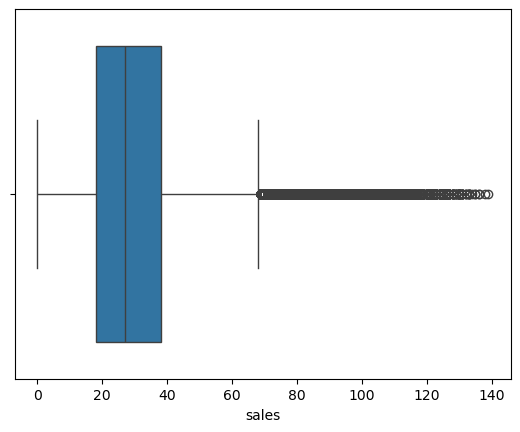

In [11]:
# 4.3 Outlier Detection 
sns.boxplot(x=df['sales'])

plt.show()

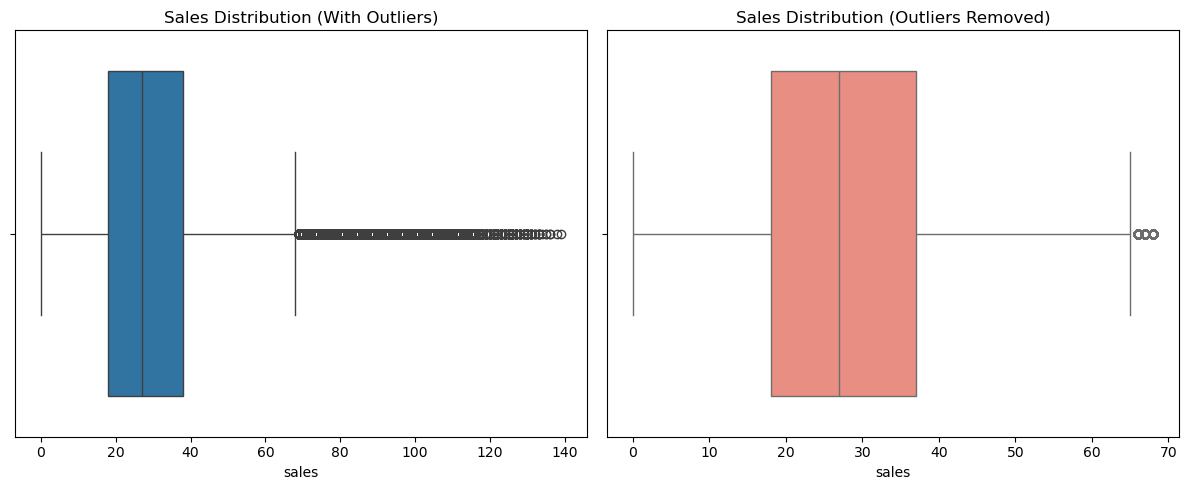

In [12]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[
    ~((df['sales'] < (Q1 - 1.5 * IQR)) |
      (df['sales'] > (Q3 + 1.5 * IQR)))].copy()

# 2. Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Before
sns.boxplot(x=df['sales'], ax=axes[0])
axes[0].set_title('Sales Distribution (With Outliers)')

# Plot After
sns.boxplot(data=df_clean, x='sales', ax=axes[1], color='salmon')
axes[1].set_title('Sales Distribution (Outliers Removed)')

plt.tight_layout()
plt.show()

#### 4.4 Feature Engineering

In [13]:
# Convert date column
df_clean['date'] = pd.to_datetime(df_clean['date'])

In [14]:
# Creating time-based features

df_clean['month'] = df_clean['date'].dt.month

df_clean['day_of_week'] = df_clean['date'].dt.dayofweek

df_clean['year'] = df_clean['date'].dt.year

In [15]:
# creating historical sales features
df_clean['lag_7'] = df_clean['sales'].shift(7)
df_clean['lag_30'] = df_clean['sales'].shift(30)

# Rolling mean

df_clean['rolling_mean_7'] = (
                               df['sales']
                               .rolling(window=7)
        .mean())

df_clean['rolling_mean_30'] = (
    df['sales']
    .rolling(window=30)
    .mean())

In [16]:
# Remove NaN values created by LAGS
df_clean.dropna(inplace=True)

In [17]:
# Create Demand Classes

def classify_demand(x):

    if x < 30:
        return 0

    elif x < 60:
        return 1

    else:
        return 2

df_clean['demand_class'] = (df_clean['sales']
                           .apply(classify_demand))


In [18]:
# Select Features
features = [
    'store_id',
    'item_id',
    'month',
    'day_of_week',
    'lag_7',
    'rolling_mean_7',
    'rolling_mean_30']

X = df_clean[features]

y = df_clean['demand_class']

print(X.head(11))

   store_id item_id  month  day_of_week  lag_7  rolling_mean_7  \
30  store_1  item_1      1            3   40.0       44.142857   
31  store_1  item_1      2            4   38.0       44.571429   
32  store_1  item_1      2            5   34.0       44.571429   
33  store_1  item_1      2            6   40.0       43.714286   
34  store_1  item_1      2            0   44.0       46.571429   
35  store_1  item_1      2            1   46.0       47.714286   
36  store_1  item_1      2            2   57.0       47.857143   
37  store_1  item_1      2            3   50.0       48.285714   
38  store_1  item_1      2            4   41.0       48.000000   
39  store_1  item_1      2            5   34.0       50.285714   
40  store_1  item_1      2            6   34.0       53.571429   

    rolling_mean_30  
30        43.066667  
31        42.666667  
32        42.500000  
33        42.466667  
34        42.900000  
35        43.433333  
36        43.866667  
37        44.033333  
38       

In [19]:
#Convert categorical text columns into 0s and 1s
X_encoded = pd.get_dummies(df_clean.drop(columns=['sales', 'date']), columns=['store_id', 'item_id'])

In [20]:
# Scale feature
scaler = StandardScaler() 

X_scaled = scaler.fit_transform(X_encoded)

#### 4.5 FEATURE SCALING + TRAIN TEST SPLIT

In [ ]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.02,
    random_state=42)

### 4.6  EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
# Checking Class Distribution 
sns.countplot(
    x='demand_class',
    data=df_clean)

plt.title("Demand Class Distribution")

plt.show()

In [ ]:
# Analyse monthly sales trend

plt.figure(figsize=(10,5))

# Monthly trend

monthly_sales = (
    df_clean.groupby('month')['sales']
    .sum()
    .reset_index())

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['month'],
    monthly_sales['sales'],
    marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
#Analysing Correlation Heatmap

# Select numerical columns
numeric_df = df_clean.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#Demand Distribution Plot

plt.figure(figsize=(10,5))

sns.histplot(
    df['sales'],
    bins=50,
    kde=True)

plt.title("Sales Demand Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Boxplot

plt.figure(figsize=(12,6))

sns.boxplot(
    x='month',
    y='sales',
    data=df_clean)

plt.title("Monthly Sales Boxplot")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [ ]:
# PCA Cluster Visualisation 
pca_features = df_clean[[
    'sales',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30']]

# Standardise data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(pca_features)

# PCA transformation
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42)

clusters = kmeans.fit_predict(pca_components)

# Create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1','PCA2'])

pca_df['Cluster'] = clusters

# Plot PCA clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1')

plt.title("PCA Cluster Visualisation")

plt.show()

# 5. Implementation and Evaluation

#### 5.1 Multilayer Perceptron (MLP)